In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/5. Clustering/crime_data.csv', index_col = 0)
df.head(5)

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [10]:
df.shape; df.isnull().sum(); df.dtypes; df.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


In [11]:
df.columns = df.columns.str.strip()
df.rename(columns={"Unnamed: 0": "State"}, inplace=True)
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


Text(0, 0.5, 'Count')

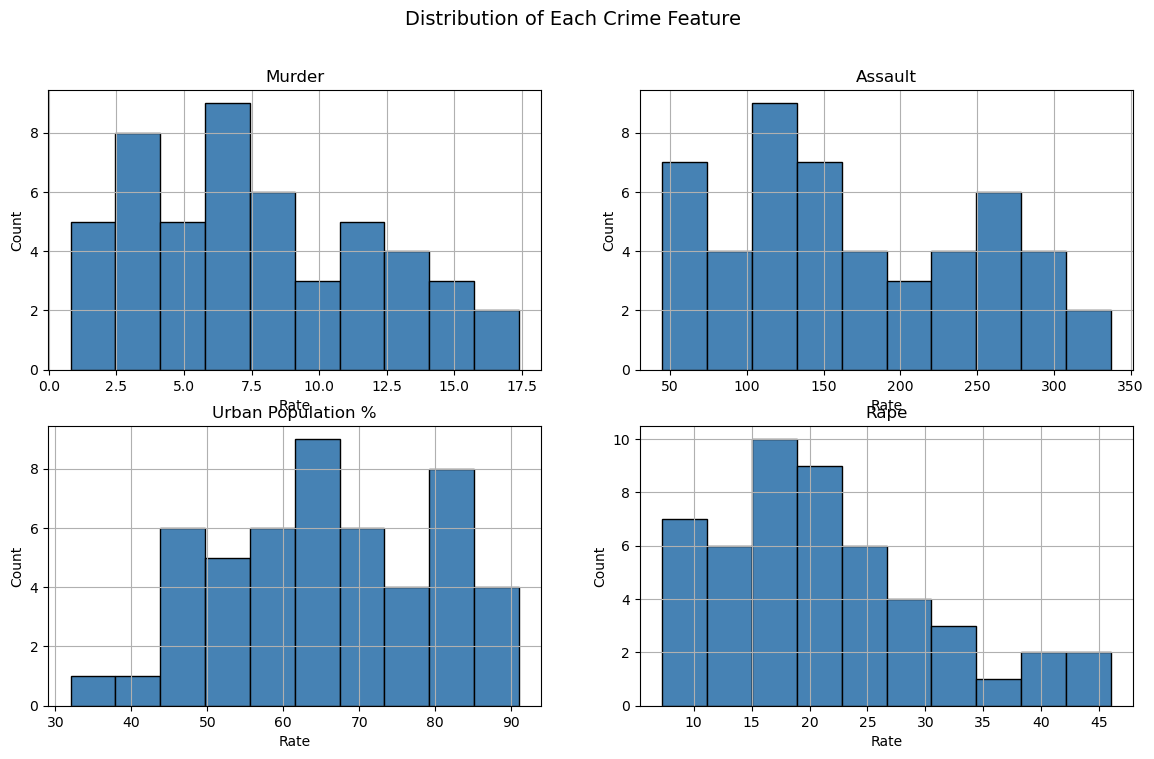

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution of Each Crime Feature', fontsize=14)

df['Murder'].hist(ax=axes[0,0], bins=10, color='steelblue', edgecolor='black')
axes[0,0].set_title('Murder')
axes[0,0].set_xlabel('Rate')
axes[0,0].set_ylabel('Count')

df['Assault'].hist(ax=axes[0,1], bins=10, color='steelblue', edgecolor='black')
axes[0,1].set_title('Assault')
axes[0,1].set_xlabel('Rate')
axes[0,1].set_ylabel('Count')

df['UrbanPop'].hist(ax=axes[1,0], bins=10, color='steelblue', edgecolor='black')
axes[1,0].set_title('Urban Population %')
axes[1,0].set_xlabel('Rate')
axes[1,0].set_ylabel('Count')

df['Rape'].hist(ax=axes[1,1], bins=10, color='steelblue', edgecolor='black')
axes[1,1].set_title('Rape')
axes[1,1].set_xlabel('Rate')
axes[1,1].set_ylabel('Count')

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [13]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = km.fit_predict(X_scaled)

K    | Inertia    | Silhouettes
___________________________________
K=2 |         105 |0.4085
K=3 |          80 |0.3081
K=4 |          58 |0.3397
K=5 |          50 |0.3008
K=6 |          44 |0.2939
K=7 |          41 |0.2742
K=8 |          36 |0.2357


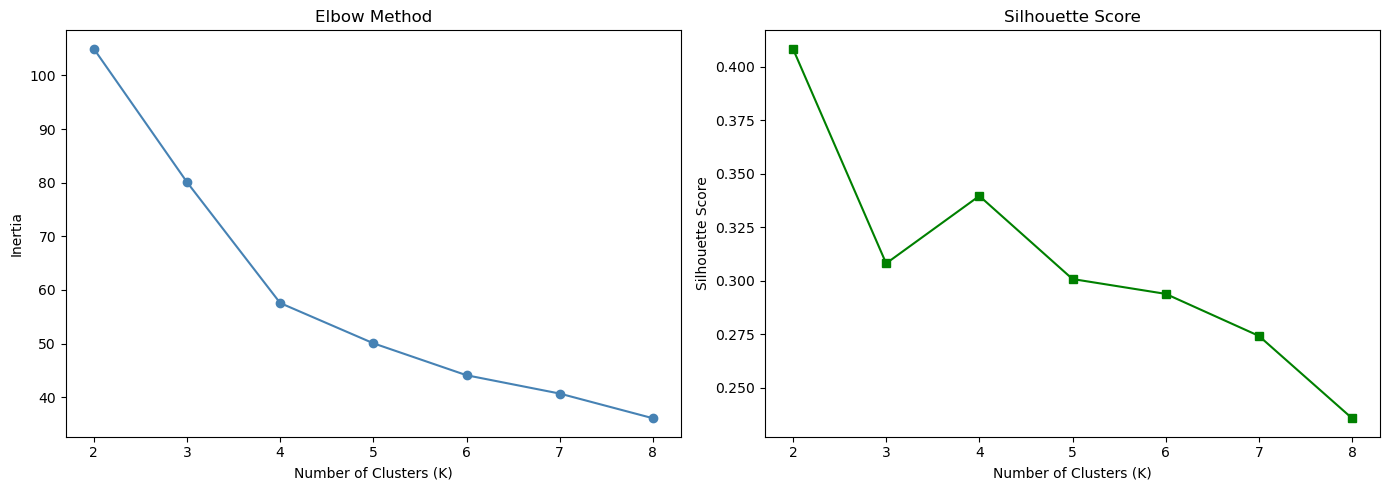

In [14]:
inertias = []
silhouettes = []
K_range = range(2,9)

for k in K_range:
    km =  KMeans(n_clusters=k, random_state=42, n_init=10)
    layer = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled,layer))

print("K    | Inertia    | Silhouettes")
print("_"*35)
for k, iner, sil in zip(K_range,inertias,silhouettes):
    print(f"K={k} |{iner:>12,.0f} |{sil:.4f}")  

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 's-', color='green')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

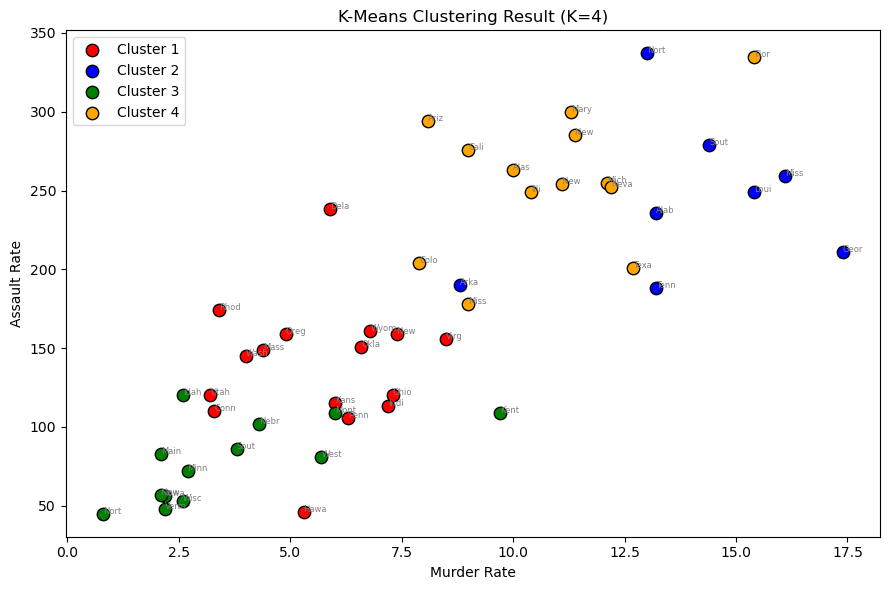


=== Average Values Per Cluster (K-Means) ===
                Murder  Assault  UrbanPop   Rape
KMeans_Cluster                                  
0                 5.66   138.88     73.88  18.78
1                13.94   243.62     53.75  21.41
2                 3.60    78.54     52.08  12.18
3                10.82   257.38     76.00  33.19

=== States in Each Cluster ===

Cluster 1: Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

Cluster 2: Alabama, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee

Cluster 3: Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Cluster 4: Alaska, Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Missouri, Nevada, New Mexico, New York, Texas


In [16]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['red', 'blue', 'green', 'orange']
for cl in range(4):
    mask = df['KMeans_Cluster'] == cl
    ax.scatter(df[mask]['Murder'], df[mask]['Assault'],
               color=colors[cl], label=f'Cluster {cl+1}', s=80, edgecolors='black')
    for state in df[mask].index:
        ax.annotate(state[:4], (df.loc[state,'Murder'], df.loc[state,'Assault']), fontsize=6, color='gray')
ax.set_xlabel('Murder Rate')
ax.set_ylabel('Assault Rate')
ax.set_title('K-Means Clustering Result (K=4)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Average Values Per Cluster (K-Means) ===")
print(df.groupby('KMeans_Cluster')[['Murder','Assault','UrbanPop','Rape']].mean().round(2))

# Print which states are in each cluster
print("\n=== States in Each Cluster ===")
for c in range(4):
    states = df[df['KMeans_Cluster'] == c].index.tolist()
    print(f"\nCluster {c+1}: {', '.join(states)}")


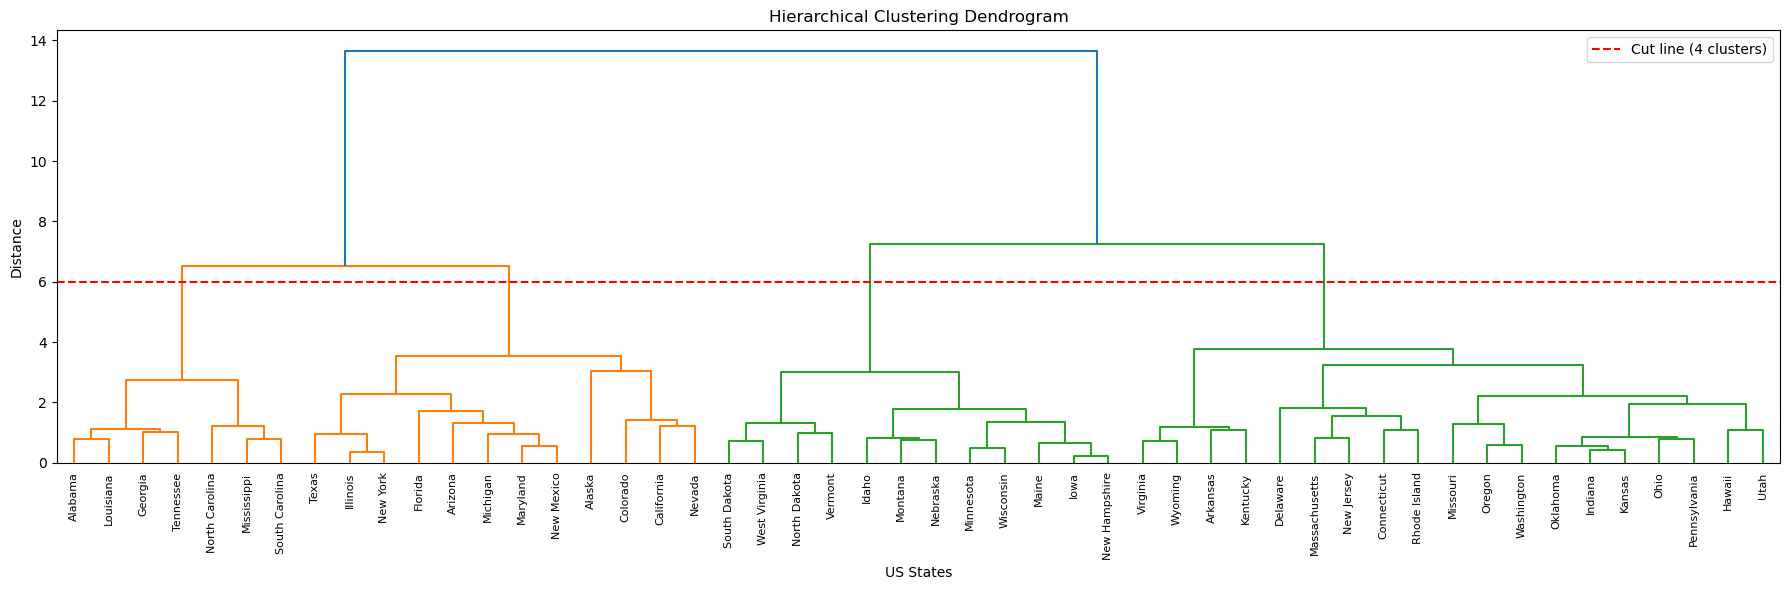

In [17]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(Z, labels=df.index.tolist(), ax=ax, leaf_font_size=8)
ax.axhline(y=6, color='red', linestyle='--', label='Cut line (4 clusters)')
ax.set_title('Hierarchical Clustering Dendrogram')
ax.set_xlabel('US States')
ax.set_ylabel('Distance')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

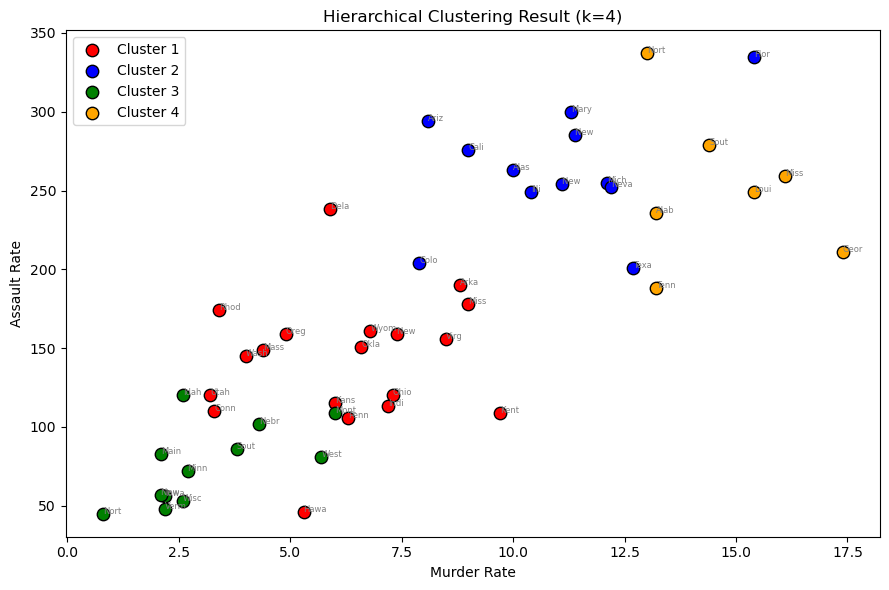


=== Average Values Per Cluster (Hierarchical) ===
            Murder  Assault  UrbanPop   Rape
HC_Cluster                                  
0             6.21   142.05     71.26  19.18
1            10.97   264.00     76.50  33.61
2             3.09    76.00     52.08  11.83
3            14.67   251.29     54.29  21.69


In [18]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['HC_Cluster'] = hc.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(4):
    mask = df['HC_Cluster'] == cl
    ax.scatter(df[mask]['Murder'], df[mask]['Assault'],
               color=colors[cl], label=f'Cluster {cl+1}', s=80, edgecolors='black')
    for state in df[mask].index:
        ax.annotate(state[:4], (df.loc[state,'Murder'], df.loc[state,'Assault']), fontsize=6, color='gray')
ax.set_xlabel('Murder Rate')
ax.set_ylabel('Assault Rate')
ax.set_title('Hierarchical Clustering Result (k=4)')
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Average Values Per Cluster (Hierarchical) ===")
print(df.groupby('HC_Cluster')[['Murder','Assault','UrbanPop','Rape']].mean().round(2))

#  The 4 Clusters & What They Mean
## Cluster 1 — Medium Crime, Urban States
States like Connecticut, Ohio, Virginia, New Jersey

Average murder: 5.7 | Assault: 138 | UrbanPop: 74%
These are moderately urban states with below-average crime. Safe but not the safest.

## Cluster 2 — High Violent Crime, Rural South
States like Alabama, Georgia, Mississippi, Tennessee, North Carolina

Average murder: 13.9 | Assault: 243 | UrbanPop: 54%
Highest murder and assault rates despite being less urbanized. This is the most dangerous cluster. Mostly Southern states.

## Cluster 3 — Low Crime, Rural States
States like Iowa, Vermont, North Dakota, Maine, Wisconsin

Average murder: 3.6 | Assault: 78 | UrbanPop: 52%
Safest cluster across all crime types. Mostly rural Midwest and Northeast states.

## Cluster 4 — High All-Round Crime, Urban States
States like California, Nevada, New York, Florida, Texas

Average murder: 10.8 | Assault: 257 | UrbanPop: 76%
Highest rape rates and assault, highly urbanized. Big populated states fall here.

# Overall Takeaways
1. Geography matters — Southern states consistently show higher violent crime (Cluster 2), while Midwest/Northeast rural states are the safest (Cluster 3).
2. Urbanization ≠ always more crime — Cluster 2 (rural South) has higher murder than Cluster 1 (urban states). So being urban doesn't automatically mean dangerous.
3. Murder and Assault go hand in hand — Correlation of 0.8 means if a state has high murder, it almost certainly has high assault too.
4. Rape is more linked to urban states — Cluster 4 (most urban) has the highest rape rates, suggesting this crime type scales more with city size than others.
5. UrbanPop is the weakest predictor — It has the lowest correlation with other crimes, meaning you can't predict crime levels just from how urban a state is.
6. Both clustering methods agree — K-Means and Hierarchical clustering produced very similar groupings, which means the 4-cluster result is reliable and stable.